# Pronóstico de ventas y diagnóstico de inventario

Predicción mensual de ventas por producto (250 productos) con XGBoost y pronóstico recursivo,<br>
junto con el cálculo de stock de seguridad y punto de reorden para reducir pérdidas por quiebres de stock.

In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Mis funciones
from funciones import to_long, crear_features

# Modelos ML
import xgboost as xgb

# Evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Rutas
PROJECT_DIR = Path("..")
DATA_DIR = PROJECT_DIR / "data"
NOTE_DIR = PROJECT_DIR / "notebooks"


In [3]:
# Ver archivos en la carpeta notebooks
print("Archivos en notebooks:", [f.name for f in Path(".").iterdir()])

# Ver archivos en la raíz del proyecto
print("Archivos en la raíz:", [f.name for f in Path("..").iterdir()])

Archivos en notebooks: ['funciones.py', 'proyecto.ipynb', '__pycache__']
Archivos en la raíz: ['.git', '.gitignore', 'data', 'notebooks', 'p4_venv', 'predicciones_2026.csv', 'README.md', 'requirements.txt']


In [4]:
# Cargando datasets
productos = pd.read_csv(DATA_DIR /'products_parameters.csv')
ventas_train_23_24 = pd.read_csv(DATA_DIR /'sales_train_2023_2024.csv')
ventas_test_25 = pd.read_csv(DATA_DIR/'sales_test_2025.csv')

In [5]:
print(f"Productos: {productos.shape}")
print(f"Ventas entrenamiento 2023-2024: {ventas_train_23_24.shape}")
print(f"Ventas prueba 2025: {ventas_test_25.shape}")

Productos: (250, 7)
Ventas entrenamiento 2023-2024: (500, 27)
Ventas prueba 2025: (500, 15)


In [6]:
# tipos de datos y nulos
productos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ProductID                        250 non-null    object 
 1   Product_name                     250 non-null    object 
 2   Storage_cost_PLN_per_unit_month  250 non-null    float64
 3   Shelf_life_months                250 non-null    int64  
 4   Lead_time_months                 250 non-null    int64  
 5   Safety_stock_months              250 non-null    float64
 6   Price_PLN_per_unit               250 non-null    float64
dtypes: float64(3), int64(2), object(2)
memory usage: 13.8+ KB


In [7]:
ventas_train_23_24.head()

,ProductID,Product_name,Type,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,...,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
0,P001,Product 001,Sales,56,47,43,40,50,72,66,...,44,55,44,61,81,59,46,53,63,47
1,P001,Product 001,Inventory_level,219,172,129,89,39,237,171,...,99,44,0,229,148,89,43,366,303,256
2,P002,Product 002,Sales,34,29,34,29,28,32,37,...,28,33,35,31,37,33,32,41,25,29
3,P002,Product 002,Inventory_level,200,171,137,108,80,48,11,...,4,265,230,199,162,129,97,56,31,2
4,P003,Product 003,Sales,67,62,68,55,57,59,61,...,78,70,71,70,70,53,63,82,76,72


In [8]:
# Convertimos de formato ancho a largo
ventas_long_train_23_24 = to_long(ventas_train_23_24)
ventas_long_train_23_24.head()

,ProductID,Product_name,Type,Año_Mes,Cantidad,Fecha,Anio,Mes
0,P001,Product 001,Sales,2023-01,56,2023-01-01,2023,1
1,P001,Product 001,Inventory_level,2023-01,219,2023-01-01,2023,1
2,P002,Product 002,Sales,2023-01,34,2023-01-01,2023,1
3,P002,Product 002,Inventory_level,2023-01,200,2023-01-01,2023,1
4,P003,Product 003,Sales,2023-01,67,2023-01-01,2023,1


In [9]:
ventas_long_test_25 = to_long(ventas_test_25)
ventas_long_test_25.head()

,ProductID,Product_name,Type,Año_Mes,Cantidad,Fecha,Anio,Mes
0,P001,Product 001,Sales,2025-01,54,2025-01-01,2025,1
1,P001,Product 001,Inventory_level,2025-01,202,2025-01-01,2025,1
2,P002,Product 002,Sales,2025-01,30,2025-01-01,2025,1
3,P002,Product 002,Inventory_level,2025-01,230,2025-01-01,2025,1
4,P003,Product 003,Sales,2025-01,68,2025-01-01,2025,1


In [10]:
# Observamos si existe alguna valor anomalo
ventas_long_test_25.describe()

,Cantidad,Fecha,Anio,Mes
count,6000.000000,6000,6000.0,6000.00000
mean,205.555500,2025-06-16 12:00:00,2025.0,6.50000
min,0.000000,2025-01-01 00:00:00,2025.0,1.00000
25%,59.000000,2025-03-24 06:00:00,2025.0,3.75000
50%,111.000000,2025-06-16 00:00:00,2025.0,6.50000
75%,237.000000,2025-09-08 12:00:00,2025.0,9.25000
max,3222.000000,2025-12-01 00:00:00,2025.0,12.00000
std,264.126131,NaN,0.0,3.45234


In [11]:
ventas_long_train_23_24.describe()

,Cantidad,Fecha,Anio,Mes
count,12000.000000,12000,12000.000000,12000.000000
mean,194.677250,2023-12-16 10:00:00.000000256,2023.500000,6.500000
min,0.000000,2023-01-01 00:00:00,2023.000000,1.000000
25%,58.000000,2023-06-23 12:00:00,2023.000000,3.750000
50%,107.000000,2023-12-16 12:00:00,2023.500000,6.500000
75%,227.000000,2024-06-08 12:00:00,2024.000000,9.250000
max,2978.000000,2024-12-01 00:00:00,2024.000000,12.000000
std,248.889218,NaN,0.500021,3.452196


In [12]:
# Filtramos solo los registros de VENTAS reales (dejamos fuera los niveles de stock)
sales_23_24 = ventas_long_train_23_24[ventas_long_train_23_24['Type'] == 'Sales'].copy()

sales_23_24.head()


,ProductID,Product_name,Type,Año_Mes,Cantidad,Fecha,Anio,Mes
0,P001,Product 001,Sales,2023-01,56,2023-01-01,2023,1
2,P002,Product 002,Sales,2023-01,34,2023-01-01,2023,1
4,P003,Product 003,Sales,2023-01,67,2023-01-01,2023,1
6,P004,Product 004,Sales,2023-01,98,2023-01-01,2023,1
8,P005,Product 005,Sales,2023-01,35,2023-01-01,2023,1


In [13]:
# agrupamos las ventas totales por fecha
ventas_mensuales = sales_23_24.groupby('Fecha')['Cantidad'].sum().reset_index()

In [14]:
ventas_mensuales.head()

,Fecha,Cantidad
0,2023-01-01,21930
1,2023-02-01,23319
2,2023-03-01,21372
3,2023-04-01,21350
4,2023-05-01,22599


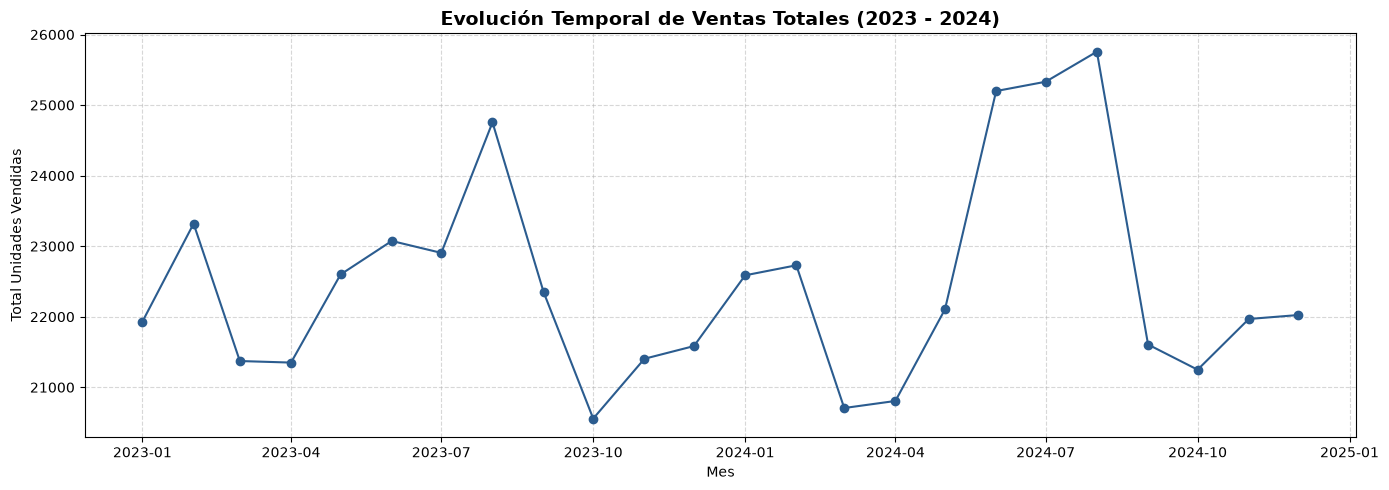

In [15]:
# Gráfico de línea de la serie temporal
plt.figure(figsize=(14, 5))

# Pasamos las columnas explícitamente: (X, Y)
plt.plot(ventas_mensuales['Fecha'], ventas_mensuales['Cantidad'], marker='o', color='#2b5c8f', linewidth=1.5)
plt.title('Evolución Temporal de Ventas Totales (2023 - 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Total Unidades Vendidas')
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks()
plt.tight_layout()

plt.show()

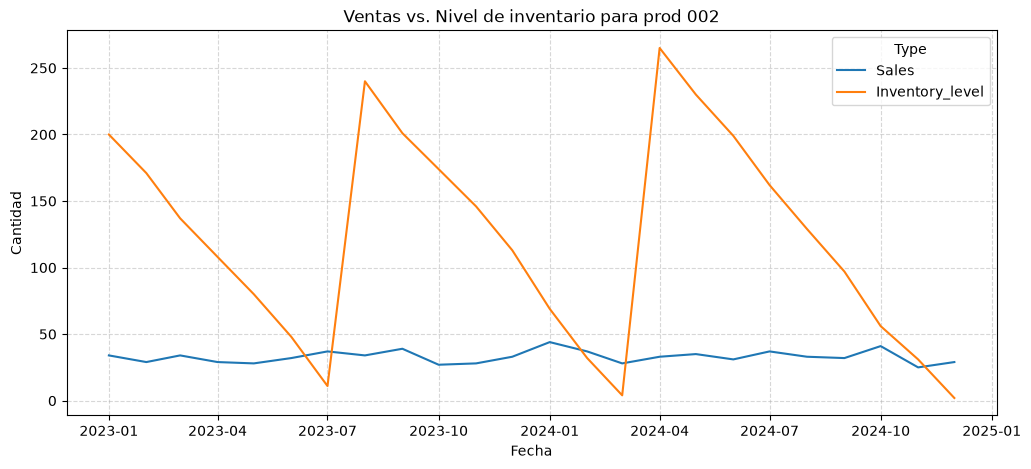

In [16]:
# Vamos a mirar un producto especifico "Product 002"
prod_002 = ventas_long_train_23_24[ventas_long_train_23_24['ProductID'] == 'P002']

# Graficas Ventas vs Inventario
plt.figure(figsize=(12, 5))
sns.lineplot(data=prod_002, x='Fecha', y='Cantidad', hue='Type')
plt.title("Ventas vs. Nivel de inventario para prod 002")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


### Predicción de 2025 con datos de 2023-2024

In [17]:
# Unimos todas las tablas
df_completo = pd.concat([ventas_long_train_23_24, ventas_long_test_25], ignore_index=True)
df_completo['Fecha'] = pd.to_datetime(df_completo['Fecha']) # nos aseguramos del formato.
df_completo.head()

,ProductID,Product_name,Type,Año_Mes,Cantidad,Fecha,Anio,Mes
0,P001,Product 001,Sales,2023-01,56,2023-01-01,2023,1
1,P001,Product 001,Inventory_level,2023-01,219,2023-01-01,2023,1
2,P002,Product 002,Sales,2023-01,34,2023-01-01,2023,1
3,P002,Product 002,Inventory_level,2023-01,200,2023-01-01,2023,1
4,P003,Product 003,Sales,2023-01,67,2023-01-01,2023,1


In [18]:
# Pivoteamos Sales y Inventory_level para convertirlos en columnas
df_pivot = df_completo.pivot_table(
    index=['ProductID', 'Fecha', 'Anio', 'Mes'],
    columns='Type',
    values='Cantidad'
).reset_index()

df_pivot = df_pivot.sort_values(by=['ProductID', 'Fecha']).reset_index(drop=True)

# Agregamos trimestre
df_pivot['Trimestre'] = df_pivot['Fecha'].dt.quarter

# Convertimos ProductID a código numérico para agregarlo como variable predictora
df_pivot['ProductID_code'] = df_pivot['ProductID'].astype('category').cat.codes

# Unimos variables de productos también
col_producto = ['ProductID', 'Price_PLN_per_unit', 'Shelf_life_months', 'Lead_time_months', 'Safety_stock_months']
df_pivot = df_pivot.merge(productos[col_producto], on='ProductID', how='left')

df_pivot.head()

,ProductID,Fecha,Anio,Mes,Inventory_level,Sales,Trimestre,ProductID_code,Price_PLN_per_unit,Shelf_life_months,Lead_time_months,Safety_stock_months
0,P001,2023-01-01,2023,1,219.0,56.0,1,0,20.62,20,3,0.7
1,P001,2023-02-01,2023,2,172.0,47.0,1,0,20.62,20,3,0.7
2,P001,2023-03-01,2023,3,129.0,43.0,1,0,20.62,20,3,0.7
3,P001,2023-04-01,2023,4,89.0,40.0,2,0,20.62,20,3,0.7
4,P001,2023-05-01,2023,5,39.0,50.0,2,0,20.62,20,3,0.7


In [19]:
# Identificar meses con stockout (2023-2025)
stockouts = df_pivot[df_pivot['Inventory_level'] == 0].copy()

# Identificar meses con stockout (solo 2025)
stockouts_25 = df_pivot[(df_pivot['Inventory_level'] == 0) & (df_pivot['Anio'] == 2025)].copy()

print(f"Total de meses con stockout en 2025: {len(stockouts_25)}")
print(f"Total de meses con stockout historico 2023-2025: {len(stockouts)}")
stockouts.head()

Total de meses con stockout en 2025: 57
Total de meses con stockout historico 2023-2025: 182


,ProductID,Fecha,Anio,Mes,Inventory_level,Sales,Trimestre,ProductID_code,Price_PLN_per_unit,Shelf_life_months,Lead_time_months,Safety_stock_months
16,P001,2024-05-01,2024,5,0.0,44.0,2,0,20.62,20,3,0.7
211,P006,2025-08-01,2025,8,0.0,40.0,3,5,35.65,14,3,0.9
238,P007,2024-11-01,2024,11,0.0,83.0,4,6,15.30,14,3,0.6
263,P008,2023-12-01,2023,12,0.0,141.0,4,7,8.61,18,1,1.3
268,P008,2024-05-01,2024,5,0.0,432.0,2,7,8.61,18,1,1.3


In [20]:
# Estimar ventas perdidas
# Venta promedio mensual SOLO en meses donde SÍ había stock (> 0), usando el histórico 2023-2024
sales_prom = (df_pivot[(df_pivot['Inventory_level'] > 0) & (df_pivot['Anio'] <= 2024)]
              .groupby('ProductID')['Sales'].mean().reset_index())
sales_prom.columns = ['ProductID', 'Venta_Promedio_Mensual']
sales_prom.head()

,ProductID,Venta_Promedio_Mensual
0,P001,53.434783
1,P002,32.875000
2,P003,67.083333
3,P004,126.208333
4,P005,32.625000


In [21]:
# Unir ese promedio a la tabla de stockouts
stockouts_25 = stockouts_25.merge(sales_prom, on='ProductID', how='left')
stockouts = stockouts.merge(sales_prom, on='ProductID', how='left')

In [22]:
stockouts_25.head()

,ProductID,Fecha,Anio,Mes,Inventory_level,Sales,Trimestre,ProductID_code,Price_PLN_per_unit,Shelf_life_months,Lead_time_months,Safety_stock_months,Venta_Promedio_Mensual
0,P006,2025-08-01,2025,8,0.0,40.0,3,5,35.65,14,3,0.9,50.583333
1,P010,2025-08-01,2025,8,0.0,84.0,3,9,22.46,24,2,1.4,79.347826
2,P013,2025-04-01,2025,4,0.0,200.0,2,12,8.00,9,1,1.2,138.608696
3,P016,2025-06-01,2025,6,0.0,64.0,2,15,33.66,10,1,1.9,72.000000
4,P017,2025-12-01,2025,12,0.0,49.0,4,16,46.90,17,2,1.0,49.541667


In [23]:
# Calcular unidades perdidas
stockouts_25['Unidades_Perdidas'] = stockouts_25['Venta_Promedio_Mensual'] - stockouts_25['Sales']
stockouts_25.loc[stockouts_25['Unidades_Perdidas'] < 0, 'Unidades_Perdidas'] = 0

In [24]:
# Convertir unidades perdidas a dinero (PLN)
stockouts_25['Perdida_PLN'] = stockouts_25['Unidades_Perdidas'] * stockouts_25['Price_PLN_per_unit']
stockouts_25.head()

,ProductID,Fecha,Anio,Mes,Inventory_level,Sales,Trimestre,ProductID_code,Price_PLN_per_unit,Shelf_life_months,Lead_time_months,Safety_stock_months,Venta_Promedio_Mensual,Unidades_Perdidas,Perdida_PLN
0,P006,2025-08-01,2025,8,0.0,40.0,3,5,35.65,14,3,0.9,50.583333,10.583333,377.295833
1,P010,2025-08-01,2025,8,0.0,84.0,3,9,22.46,24,2,1.4,79.347826,0.000000,0.000000
2,P013,2025-04-01,2025,4,0.0,200.0,2,12,8.00,9,1,1.2,138.608696,0.000000,0.000000
3,P016,2025-06-01,2025,6,0.0,64.0,2,15,33.66,10,1,1.9,72.000000,8.000000,269.280000
4,P017,2025-12-01,2025,12,0.0,49.0,4,16,46.90,17,2,1.0,49.541667,0.541667,25.404167


In [25]:
# Agrupar por producto y rankear
perdida_por_producto = stockouts_25.groupby(['ProductID']).agg(
    Total_Meses_Stockout=('Fecha', 'nunique'),
    Total_Unidades_Perdidas=('Unidades_Perdidas', 'sum'),
    Total_PLN_Perdido=('Perdida_PLN', 'sum')
).reset_index()

perdida_por_producto = perdida_por_producto.sort_values('Total_PLN_Perdido', ascending=False)

print("\n--- TOP 10 PRODUCTOS CON MAYOR PÉRDIDA POR STOCKOUT (2025) ---")
print(perdida_por_producto.head(10))


--- TOP 10 PRODUCTOS CON MAYOR PÉRDIDA POR STOCKOUT (2025) ---
   ProductID  Total_Meses_Stockout  Total_Unidades_Perdidas  Total_PLN_Perdido
43      P181                     1                 6.636364         901.550000
19      P080                     1                14.521739         565.331304
30      P131                     1                13.666667         543.796667
45      P188                     1                 9.458333         410.680833
0       P006                     1                10.583333         377.295833
39      P171                     1                21.380952         377.160000
26      P117                     1                17.318182         365.067273
3       P016                     1                 8.000000         269.280000
49      P210                     2                33.523810         268.190476
24      P106                     1                 5.458333         254.740417


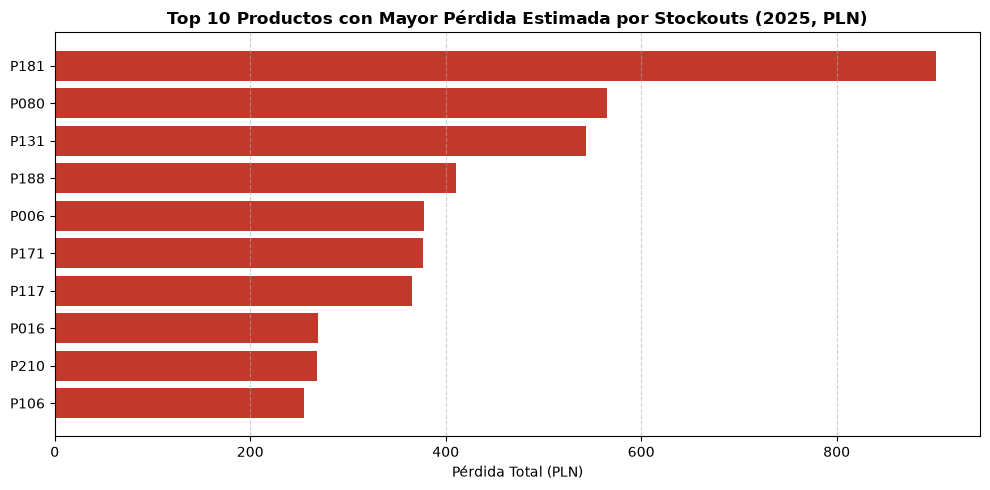

In [26]:
# Visualización
top_10 = perdida_por_producto.head(10).sort_values('Total_PLN_Perdido', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(top_10['ProductID'], top_10['Total_PLN_Perdido'], color='#c0392b')
plt.title('Top 10 Productos con Mayor Pérdida Estimada por Stockouts (2025, PLN)', fontsize=12, fontweight='bold')
plt.xlabel('Pérdida Total (PLN)', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [27]:
stockouts['Unidades_Perdidas'] = (stockouts['Venta_Promedio_Mensual'] - stockouts['Sales']).clip(lower=0)
stockouts['Perdida_PLN'] = stockouts['Unidades_Perdidas'] * stockouts['Price_PLN_per_unit']
print(f"Pérdida acumulada 2023-2025: {stockouts['Perdida_PLN'].sum():,.2f} PLN")

Pérdida acumulada 2023-2025: 24,537.52 PLN


### Diagnóstico de Inventario Óptimo Retrospectivo (2025)
Calculamos el Stock de Seguridad y Punto de Reorden teórico basado en la demanda real observada en 2025.<br>

In [28]:
# Calculamos demanda mensual promedio por producto 2025
demanda = (df_pivot[df_pivot['Anio'] == 2025]
           .groupby('ProductID')['Sales'].mean()
           .reset_index(name='Demanda_Mensual'))

# unimos parámetros de inventario
inv = demanda.merge(productos[['ProductID', 'Product_name', 'Safety_stock_months',
                               'Lead_time_months', 'Price_PLN_per_unit']],
                               on='ProductID', how='left')

# Stock de seguridad y punto de reorden
inv['Stock_Seguridad'] = inv['Demanda_Mensual'] * inv['Safety_stock_months']
inv['Punto_Reorden'] = inv['Demanda_Mensual'] * inv['Lead_time_months'] + inv['Stock_Seguridad']

# Cruzamos con las pérdidas por sctockout ya calculadas 
inv = inv.merge(perdida_por_producto, on='ProductID', how='left')

# Rellenamos con 0 los productos que no sufrieron perdidas
inv[['Total_Meses_Stockout', 'Total_Unidades_Perdidas', 'Total_PLN_Perdido']] = (
    inv[['Total_Meses_Stockout', 'Total_Unidades_Perdidas', 'Total_PLN_Perdido']].fillna(0)
)

inv = inv.sort_values('Total_PLN_Perdido', ascending=False)

# Total recuperable si se mantiene el inventario óptimo
print(f'Pérdida total por stockouts en 2025: {inv["Total_PLN_Perdido"].sum():,.2f} PLN')

inv.round(2).head(10)

Pérdida total por stockouts en 2025: 5,714.65 PLN


,ProductID,Demanda_Mensual,Product_name,Safety_stock_months,Lead_time_months,Price_PLN_per_unit,Stock_Seguridad,Punto_Reorden,Total_Meses_Stockout,Total_Unidades_Perdidas,Total_PLN_Perdido
180,P181,123.17,Product 181,1.4,1,135.85,172.43,295.60,1.0,6.64,901.55
79,P080,69.00,Product 080,1.9,1,38.93,131.10,200.10,1.0,14.52,565.33
130,P131,97.42,Product 131,1.6,2,39.79,155.87,350.70,1.0,13.67,543.80
187,P188,158.00,Product 188,1.5,1,43.42,237.00,395.00,1.0,9.46,410.68
5,P006,50.58,Product 006,0.9,3,35.65,45.53,197.28,1.0,10.58,377.30
170,P171,154.25,Product 171,1.1,2,17.64,169.68,478.18,1.0,21.38,377.16
116,P117,98.67,Product 117,1.5,2,21.08,148.00,345.33,1.0,17.32,365.07
15,P016,69.83,Product 016,1.9,1,33.66,132.68,202.52,1.0,8.00,269.28
209,P210,248.75,Product 210,1.3,2,8.00,323.38,820.88,2.0,33.52,268.19
105,P106,53.42,Product 106,1.8,1,46.67,96.15,149.57,1.0,5.46,254.74


In [29]:
# Preparación de variables para el entrenamiento (2023 - 2024)

# Copiamos datos históricos hasta 2024 para calcular lags de entrenamiento.
df_train_lags = df_pivot[df_pivot['Anio'] <= 2024].copy()

# lags de entrenamiento
df_train_lags = crear_features(df_train_lags)

# Eliminamos las filas iniciales que quedaron con Nulos por los Lags
train_clean = df_train_lags.dropna().copy()

# Definimos variables de entrada (x) y variables a predecir (y)
var_pred = ['ProductID_code', 'Mes', 'Trimestre',
            'Price_PLN_per_unit', 'Shelf_life_months', 'Lead_time_months', 'Safety_stock_months',
            'Ventas_Lag_1', 'Ventas_Lag_3', 'Ventas_Lag_6',
            'Ventas_Lag_12', 'Ventas_Rolling_3']
var_obj = 'Sales'

X_train = train_clean[var_pred]
y_train = train_clean[var_obj]

print(f"Set de entrenamiento limpio: {X_train.shape[0]} registros")

Set de entrenamiento limpio: 5250 registros


### Creamos y entrenamos el modelo XGBoost

In [30]:
modelo_xgb = xgb.XGBRegressor(
    n_estimators=150,
    learning_rate=0.08,
    max_depth=5,
    random_state=42
)

# lo entrenamos con los datos de 2023 - 2024
modelo_xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [31]:
# Predicción Recursiva Mes a Mes para 2025

# Guardamos los valores reales de 2025 para evaluarlo al final
df_real_25 = df_pivot[df_pivot['Anio'] == 2025][['ProductID', 'Fecha', 'Sales']].copy()
df_real_25.rename(columns={'Sales': 'Sales_Real'}, inplace = True)


# Creamos una estructura dinámica para que 'sales' de 2025 se vaya actualizando
df_rec = df_pivot.copy()

# Blanqueamos las ventas de 2025 para no usar información futura
df_rec.loc[df_rec['Anio'] == 2025, 'Sales'] = np.nan

# Obtenemos los meses de 2025 ordenados
fechas_2025 = sorted(df_rec[df_rec['Anio'] == 2025]['Fecha'].unique())

# BUCLE RECURSIVO: Predecimos un mes y alimentamos el siguiente
for fecha_actual in fechas_2025:
    
    # Recalcular Lags usando lo acumulado (historia real + predicciones previas)
    df_rec = crear_features(df_rec)
    
    # Filtrar únicamente las filas de la fecha actual
    mask_mes = df_rec['Fecha'] == fecha_actual
    X_mes = df_rec.loc[mask_mes, var_pred]
    
    preds = np.maximum(modelo_xgb.predict(X_mes), 0) # Aseguramos ventas >= 0
    
    # Asignar las predicciones a 'Sales' para que sirvan de insumo en el siguiente mes
    df_rec.loc[mask_mes, 'Sales'] = preds

In [32]:
# Unimos las predicciones obtenidas con los datos reales
eval_2025 = df_rec[df_rec['Anio'] == 2025].merge(df_real_25, on=['ProductID', 'Fecha'], how='left')

mae = mean_absolute_error(eval_2025['Sales_Real'], eval_2025['Sales'])
rmse = np.sqrt(mean_squared_error(eval_2025['Sales_Real'], eval_2025['Sales']))

print("=" * 40)
print(" EVALUACIÓN REALISTA (RECURSIVA PANDAS) ")
print("=" * 40)
print(f"MAE  (Error Medio Absoluto): {mae:.2f} unidades")
print(f"RMSE (Error Cuadrático):    {rmse:.2f} unidades")
print("=" * 40)

 EVALUACIÓN REALISTA (RECURSIVA PANDAS) 
MAE  (Error Medio Absoluto): 24.43 unidades
RMSE (Error Cuadrático):    56.62 unidades


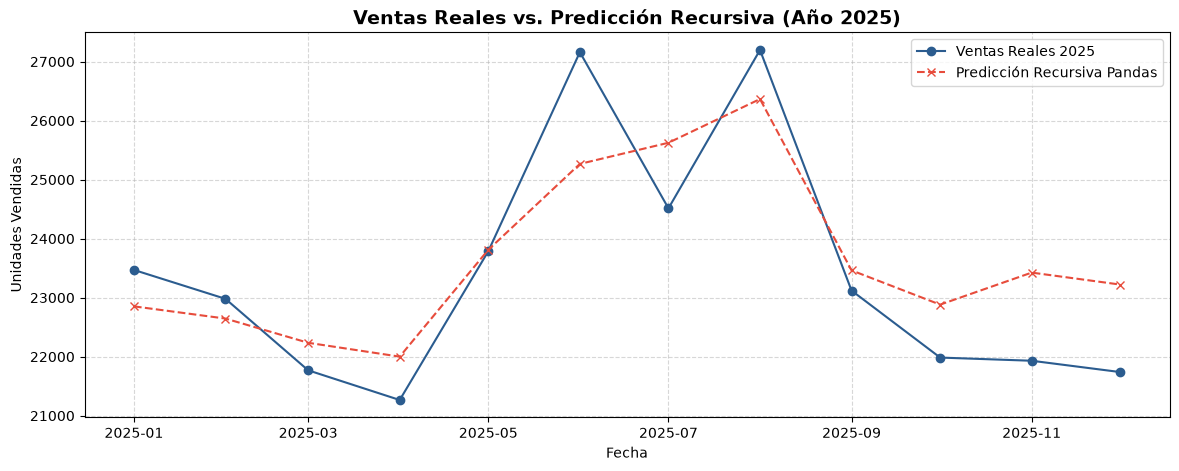

In [33]:
# Gráfico de comparación
comparativa = eval_2025.groupby('Fecha')[['Sales_Real', 'Sales']].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(comparativa['Fecha'], comparativa['Sales_Real'], label='Ventas Reales 2025', color='#2b5c8f', marker='o')
plt.plot(comparativa['Fecha'], comparativa['Sales'], label='Predicción Recursiva Pandas', color='#e74c3c', linestyle='--', marker='x')

plt.title('Ventas Reales vs. Predicción Recursiva (Año 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Unidades Vendidas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [34]:
# --- Comparación: Plan de la compañía vs Modelo (2025) ---
plan = pd.read_csv(DATA_DIR / 'financial_plan.csv')

# Ventas reales 2025 anuales por producto
real_2025 = df_real_25.groupby('ProductID')['Sales_Real'].sum().reset_index(name='Real_2025')

# Predicción 2025 anual por producto
pred_2025 = eval_2025.groupby('ProductID')['Sales'].sum().reset_index(name='Pred_2025')

# Unimos plan, real y predicción
comp = (plan[['ProductID', 'Plan_2025_units']]
        .merge(real_2025, on='ProductID')
        .merge(pred_2025, on='ProductID'))

mae_plan = mean_absolute_error(comp['Real_2025'], comp['Plan_2025_units'])
mae_modelo = mean_absolute_error(comp['Real_2025'], comp['Pred_2025'])

print("=" * 40)
print(" COMPARACIÓN ANUAL 2025 (unidades) ")
print("=" * 40)
print(f"MAE Plan compañía : {mae_plan:>10.2f} unidades")
print(f"MAE Modelo XGBoost: {mae_modelo:>10.2f} unidades")
print("=" * 40)

 COMPARACIÓN ANUAL 2025 (unidades) 
MAE Plan compañía :     129.38 unidades
MAE Modelo XGBoost:     147.06 unidades


In [35]:
tabla_comparacion = comp[['ProductID', 'Plan_2025_units', 'Pred_2025', 'Real_2025']].copy()
tabla_comparacion = tabla_comparacion.round(1)
tabla_comparacion = tabla_comparacion.rename(columns={
    'Plan_2025_units': 'Plan',
    'Pred_2025': 'Prediccion',
    'Real_2025': 'Real'
})
tabla_comparacion.head(20)

,ProductID,Plan,Prediccion,Real
0,P001,543,721.0,650.0
1,P002,360,413.5,424.0
2,P003,818,883.8,836.0
3,P004,1693,1729.4,1611.0
4,P005,321,413.0,365.0
5,P006,479,892.8,607.0
6,P007,992,992.9,909.0
7,P008,1105,1531.2,1478.0
8,P009,872,1165.5,1119.0
9,P010,1163,955.2,953.0


In [36]:
# Sesgo (error medio con signo) y MAE por producto
sesgo_plan   = (comp['Plan_2025_units'] - comp['Real_2025']).mean()
sesgo_modelo = (comp['Pred_2025'] - comp['Real_2025']).mean()

resumen = pd.DataFrame({
    'Metodo': ['Plan compania', 'Modelo XGBoost'],
    'Sesgo (unid/prod)': [sesgo_plan, sesgo_modelo],
    'MAE (unid/prod)': [
        mean_absolute_error(comp['Real_2025'], comp['Plan_2025_units']),
        mean_absolute_error(comp['Real_2025'], comp['Pred_2025'])
    ],
    'Total (250 prod)': [
        comp['Plan_2025_units'].sum(),
        comp['Pred_2025'].sum()
    ]
})
resumen['Real_total'] = comp['Real_2025'].sum()
resumen

,Metodo,Sesgo (unid/prod),MAE (unid/prod),Total (250 prod),Real_total
0,Plan compania,-84.728000,129.384000,259737.000000,280919.0
1,Modelo XGBoost,11.504232,147.060988,283795.058064,280919.0


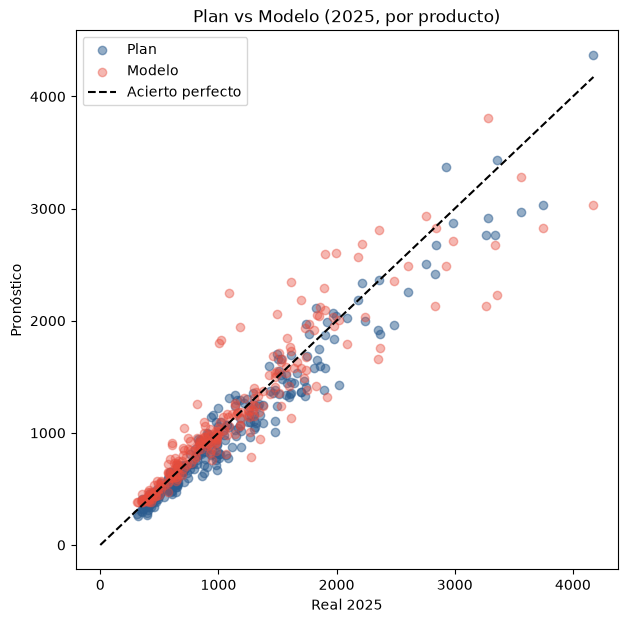

In [37]:
plt.figure(figsize=(7, 7))
plt.scatter(comp['Real_2025'], comp['Plan_2025_units'], alpha=0.5, label='Plan', color='#2b5c8f')
plt.scatter(comp['Real_2025'], comp['Pred_2025'], alpha=0.4, label='Modelo', color='#e74c3c')
plt.plot([0, comp['Real_2025'].max()], [0, comp['Real_2025'].max()], 'k--', label='Acierto perfecto')
plt.xlabel('Real 2025'); plt.ylabel('Pronóstico'); plt.legend()
plt.title('Plan vs Modelo (2025, por producto)')
plt.show()

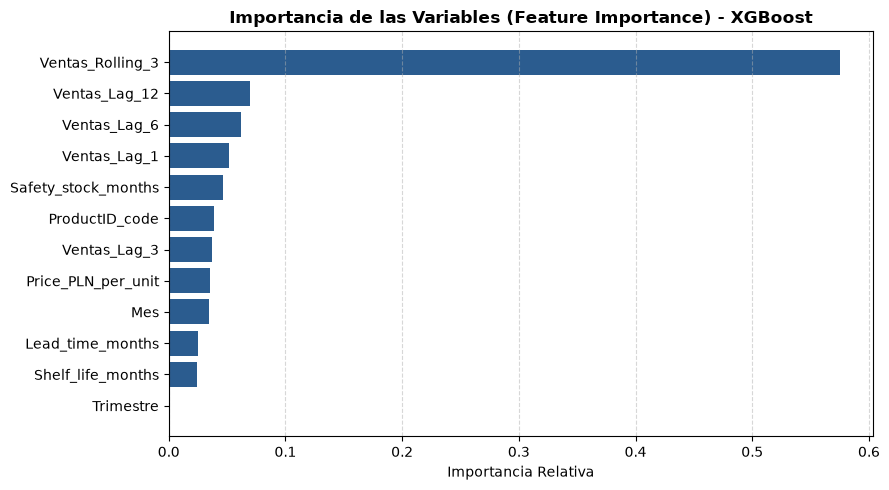

In [38]:
importances = pd.DataFrame({
    'Feature': var_pred,
    'Importance': modelo_xgb.feature_importances_
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(importances['Feature'], importances['Importance'], color='#2b5c8f')
plt.title('Importancia de las Variables (Feature Importance) - XGBoost', fontsize=12, fontweight='bold')
plt.xlabel('Importancia Relativa')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Pronosticar 2026

In [39]:
# pronóstico 2026
df_train_full = df_pivot[df_pivot['Anio'] <= 2025].copy()
df_train_full = crear_features(df_train_full)
train_full = df_train_full.dropna().copy()

X_train_full = train_full[var_pred]
y_train_full = train_full[var_obj]

modelo_2026 = xgb.XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=5, random_state=42)

modelo_2026.fit(X_train_full, y_train_full)

print(f"Modelo 2026 entrenado con {X_train_full.shape[0]} registros (2023-2025)")

Modelo 2026 entrenado con 8250 registros (2023-2025)


In [40]:
# Construimos el esqueleto de 2026
productos_unicos = df_pivot[['ProductID', 'ProductID_code', 'Price_PLN_per_unit',
                             'Shelf_life_months', 'Lead_time_months', 'Safety_stock_months']].drop_duplicates('ProductID')

fechas_2026 = pd.date_range('2026-01-01', '2026-12-01', freq='MS') # Month Start

registros = []
for fecha in fechas_2026:
    tmp = productos_unicos.copy() # Cada mes tendra sus 250 productos
    tmp['Fecha'] = fecha
    tmp['Anio'] = fecha.year
    tmp['Mes'] = fecha.month
    tmp['Trimestre'] = fecha.quarter
    tmp['Sales'] = np.nan
    registros.append(tmp)

df_2026 = pd.concat(registros, ignore_index=True)

# Juntamos el histórico (2023-2025) con el esqueleto 2026 en un solo DataFrame
df_full = pd.concat([df_pivot, df_2026], ignore_index=True).sort_values(['ProductID', 'Fecha']).reset_index(drop=True)

### Bucle recursivo 2026

In [41]:
# Copiamos df_full para trabajar sin tocar el original.
df_rec26 = df_full.copy()

fechas_26_list = sorted(df_rec26[df_rec26['Anio'] == 2026]['Fecha'].unique())

for fecha_actual in fechas_26_list:
    df_rec26 = crear_features(df_rec26)
    mask = df_rec26['Fecha'] == fecha_actual
    X_mes = df_rec26.loc[mask, var_pred]
    preds = np.maximum(modelo_2026.predict(X_mes), 0) # aseguramos que ninguna salga negativa
    df_rec26.loc[mask, 'Sales'] = preds # Escribimos las predicciones en la columna sales de ese mes

# nos quedamos solo con las filas de 2026 ya predichas.
pred_2026 = df_rec26[df_rec26['Anio'] == 2026][['ProductID', 'Fecha', 'Mes', 'Sales']].copy()

pred_2026 = pred_2026.rename(columns={'Sales': 'Unidades'})

# Unimos el nombre y el precio de cada producto
pred_2026 = pred_2026.merge(productos[['ProductID', 'Product_name', 'Price_PLN_per_unit']],
                            on='ProductID', how='left')

# Calculo el dinero
pred_2026['PLN'] = pred_2026['Unidades'] * pred_2026['Price_PLN_per_unit']

pred_2026 = pred_2026.sort_values(['ProductID', 'Fecha'])

# Exporto el CSV
pred_2026.to_csv(PROJECT_DIR / 'predicciones_2026.csv', index=False)

pred_2026.head()





,ProductID,Fecha,Mes,Unidades,Product_name,Price_PLN_per_unit,PLN
0,P001,2026-01-01,1,65.529228,Product 001,20.62,1351.212686
1,P001,2026-02-01,2,58.469040,Product 001,20.62,1205.631603
2,P001,2026-03-01,3,54.013374,Product 001,20.62,1113.755779
3,P001,2026-04-01,4,55.467476,Product 001,20.62,1143.739353
4,P001,2026-05-01,5,52.964951,Product 001,20.62,1092.137281


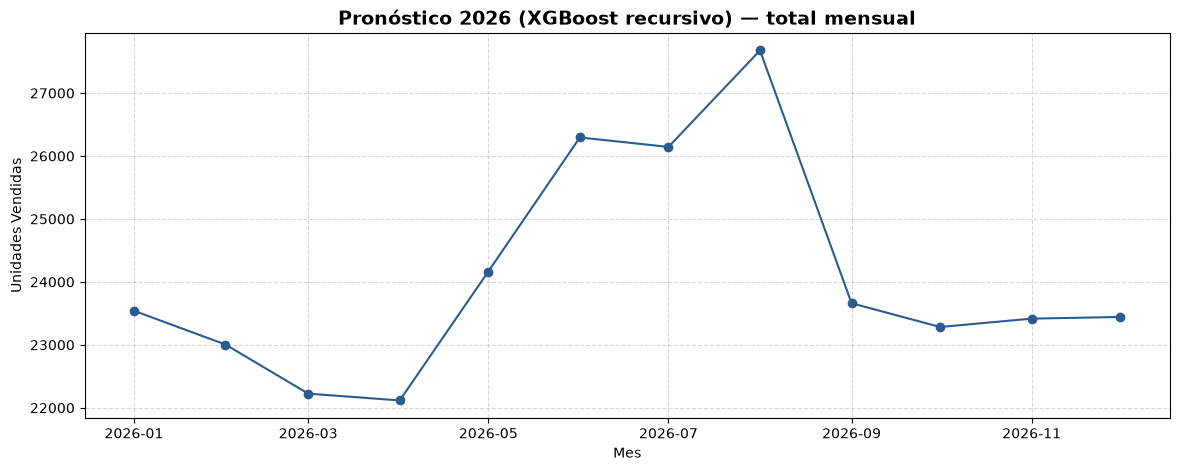

In [42]:
# Agrupa por fecha y suma → total vendido por mes en 2026.
total_2026 = pred_2026.groupby('Fecha')[['Unidades', 'PLN']].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(total_2026['Fecha'], total_2026['Unidades'], marker='o', color='#2b5c8f', linewidth=1.5)
plt.title('Pronóstico 2026 (XGBoost recursivo) — total mensual', fontsize=14, fontweight='bold')
plt.xlabel('Mes'); plt.ylabel('Unidades Vendidas')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Conclusiones

**Qué se hizo:**
- Análisis exploratorio y detección de quiebres de stock, estimando las ventas perdidas en PLN.
- Modelo XGBoost con pronóstico recursivo (lags de ventas y estacionalidad), entrenado con 2023–2024 y validado sobre 2025 **sin fuga de información**.
- Reentrenamiento con todo el histórico (2023–2025) para pronosticar 2026 mes a mes.
- Cálculo de stock de seguridad y punto de reorden por producto usando la demanda de 2025.
- Comparación del pronóstico 2025 contra el plan financiero de la compañía.

**Resultados:**
- Evaluación 2025: **MAE 24.43 / RMSE 56.62 unidades**.
- Pérdida estimada por quiebres de stock 2025: **5.715 PLN**.
- Pérdida estimada por quiebres de stock historico (2023-2025): **24.538 PLN**.
- Comparación con el plan (2025): el plan gana por producto (MAE 129 vs 147)
  pero subestima sistemáticamente (aprox 21,000 unidades por debajo del total real);
  el modelo es insesgado y acierta el total con aprox 1% de error.

**Entregables:** `predicciones_2026.csv` (unidades y PLN por producto y mes).

**Limitaciones:**
- No se usan variables de inventario en el modelo (importancia casi nula).
- Datos ruidosos y con poca estacionalidad (el lag 12 aporta poca señal).
- El plan financiero llega solo hasta 2025; no hay plan 2026 contra el cual
  validar el pronóstico de ese año.